## Modelo LSTM de una sola capa para predicción del S&P500 desde 1 de enero de 1990 hasta 1 de enero de 2024, para predecir un solo día en el futuro.

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - loss: 0.0029 - val_loss: 4.6802e-04
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - loss: 3.7858e-05 - val_loss: 6.8371e-04
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - loss: 3.6189e-05 - val_loss: 0.0011
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - loss: 3.9978e-05 - val_loss: 3.8073e-04
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - loss: 3.1185e-05 - val_loss: 3.5877e-04
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - loss: 3.3081e-05 - val_loss: 3.8046e-04
Epoch 7/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - loss: 3.1982e-05 - val_loss: 3.7959e-04
Epoch 8/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 2.7644e-05 - val_loss: 2.3702e-04
Epoch 9/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - loss: 2.6910e-05 - val_loss: 2.2611e-04
Epoch 10/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - loss: 3.1244e-05 - val_loss: 2.4875e-04
Epoch 11/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 21s 68

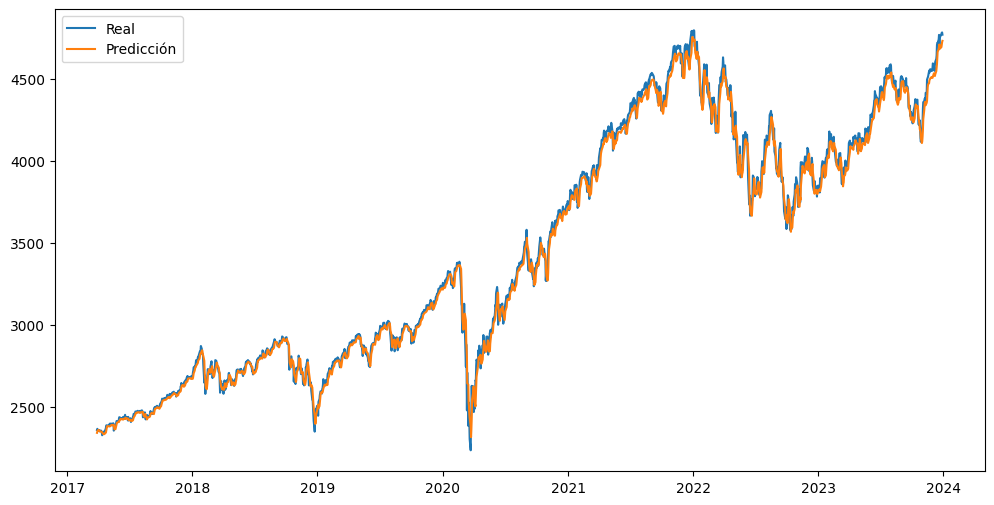

In [ ]:

import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Descargar datos históricos del S&P 500
ticker = "^GSPC"  # S&P 500
df = yf.download(ticker, start="1990-01-01", end="2024-01-01")
df = df[['Close']]  # Usamos solo el precio de cierre

# 2. Normalizar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)

# 3. Crear secuencias para entrenamiento
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Usamos 60 días de historial para predecir
X, y = create_sequences(df_scaled, seq_length)

# Dividir en entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 4. Definir la red neuronal LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

# 5. Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Entrenar el modelo en la GPU
with tf.device('/GPU:0'):  # Asegura que la RTX 4070 se use
    history = model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test))

# 7. Hacer predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Desescalar

# 8. Graficar resultados
plt.figure(figsize=(12, 6))
plt.plot(df.index[train_size+seq_length:], scaler.inverse_transform(y_test.reshape(-1, 1)), label="Real")
plt.plot(df.index[train_size+seq_length:], predictions, label="Predicción")
plt.legend()
plt.show()


## Modelo LSTM de 3 capas + Dense, para predicción del S&P500 desde 1 de enero de 1990 hasta 1 de enero de 2024, , para predecir un solo día en el futuro.

Se le agregan mas capas para tener mas precision en los pequeños detalles, recordemos que  los datos son diarios durante 34 años, en la grafica se podra ver similar el comportamiento si se usa una sola capa, pero a nivel diario puede variar bastante, por lo cual es mejor implementar mas capas, para tener mas precisión, pero se debe tener mas cuidado ya que si se usan muchas capas, el modeo deja de aprender a predecir y empieza a memorizar y reproducir lo que ya sabe y no a producir información nueva (predecir) usando lo que sabe.

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 183ms/step - loss: 0.0061 - val_loss: 0.0011
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 27s 178ms/step - loss: 3.9312e-04 - val_loss: 0.0047
Epoch 3/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 173ms/step - loss: 2.3133e-04 - val_loss: 0.0013
Epoch 4/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - loss: 2.1922e-04 - val_loss: 0.0052
Epoch 5/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - loss: 1.8775e-04 - val_loss: 0.0061
Epoch 6/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 177ms/step - loss: 1.7556e-04 - val_loss: 0.0048
Epoch 7/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 177ms/step - loss: 1.8891e-04 - val_loss: 0.0061
Epoch 8/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 179ms/step - loss: 2.0489e-04 - val_loss: 0.0061
Epoch 9/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 26s 172ms/step - loss: 1.6367e-04 - val_loss: 0.0035
Epoch 10/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - loss: 1.8754e-04 - val_loss: 0.0025
Epoch 11/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 26s 172ms/step - loss: 1.7158e-0

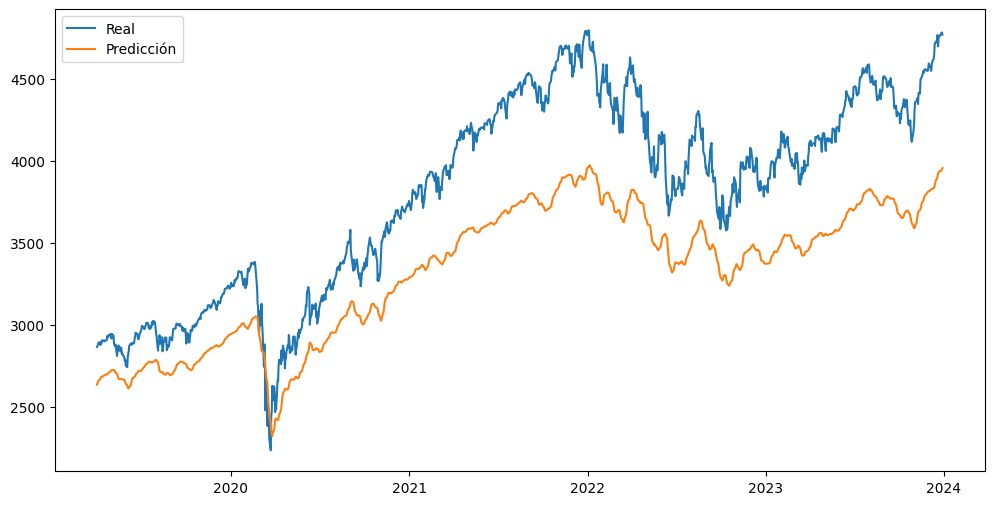

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Descargar datos del S&P 500
ticker = "^GSPC"
df = yf.download(ticker, start="2000-01-01", end="2024-01-01")
df = df[['Close']]

# Normalizar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)

# Crear secuencias de datos
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # 60 días de historial
X, y = create_sequences(df_scaled, seq_length)

# Dividir en entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Definir la red neuronal con más capas
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(25, activation='relu'),
    Dense(1)
])

# Compilar y entrenar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

with tf.device('/GPU:0'):
    model.fit(X_train, y_train, batch_size=32, epochs=25, validation_data=(X_test, y_test))

# Hacer predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(df.index[train_size+seq_length:], scaler.inverse_transform(y_test.reshape(-1, 1)), label="Real")
plt.plot(df.index[train_size+seq_length:], predictions, label="Predicción")
plt.legend()
plt.show()


## Modelo LSTM de 3 capas + Dense, para predicción del S&P500 desde 1 de enero de 1990 hasta 1 de enero de 2024, , para predecir 5 días en el futuro.

Al final se vera que la predicción no es muy buena, pero esto aunque se puede mejorar bastante, haciendo uso de computo y programación mas avanzada, no tendría mucho sentido por que no sería util mas alla de una labor didactica ya que debido al fenomeno de profesia autocumplida,no se podría sacar ventaja de una predicción tan grande, ya que al interactuar con el sistemmapara sacar ventaja, el sistema se altera respecto al analizado (comportammiento normmal) y ya la predicción hecha no se cummplira, por eso en el mundo entero todas las compañias financieras que trabajan con predicciones, lo hace con un gran equipo de computo y programación para predecir con la mas altisima presición el comportamiento del fenomeno financiero que se quiera analizar, solo unos mmilisegundos en el futuro, para luego usar otras herramientas computacionales para la compra y venta de los activos financieros analizados en esos milisegundos de predicción: a todo esto hay que sumarle que debido a que los grandes mercados financieros del mundo tienen altisimma eficiencia razon por la cual, todos los integrantes (entidades financieras del mundo) estan altammente y informadas de todos los metodos (entre ellos los predictivos) para poder sacar provecho econommico de los sistemas financieros, esto hace que aunque todos puedan predecir, se contienen entre ellos (mmercado fluctuante teoricamente justo {ver mas adelante el analisis de eficiencia del mercado con el exponente de Herst})

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 63s 234ms/step - loss: 0.0074 - val_loss: 0.0118
Epoch 2/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 70s 178ms/step - loss: 3.0033e-04 - val_loss: 0.0082
Epoch 3/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 41s 178ms/step - loss: 2.3255e-04 - val_loss: 0.0033
Epoch 4/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 38s 165ms/step - loss: 1.9495e-04 - val_loss: 0.0027
Epoch 5/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 44s 182ms/step - loss: 1.5336e-04 - val_loss: 0.0026
Epoch 6/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 38s 166ms/step - loss: 1.4091e-04 - val_loss: 7.7775e-04
Epoch 7/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - loss: 1.4956e-04 - val_loss: 0.0014
Epoch 8/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 40s 169ms/step - loss: 1.2594e-04 - val_loss: 7.1723e-04
Epoch 9/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 37s 174ms/step - loss: 1.0825e-04 - val_loss: 8.4643e-04
Epoch 10/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 40s 168ms/step - loss: 1.0692e-04 - val_loss: 5.5558e-04
Epoch 11/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 46s 191ms/step -

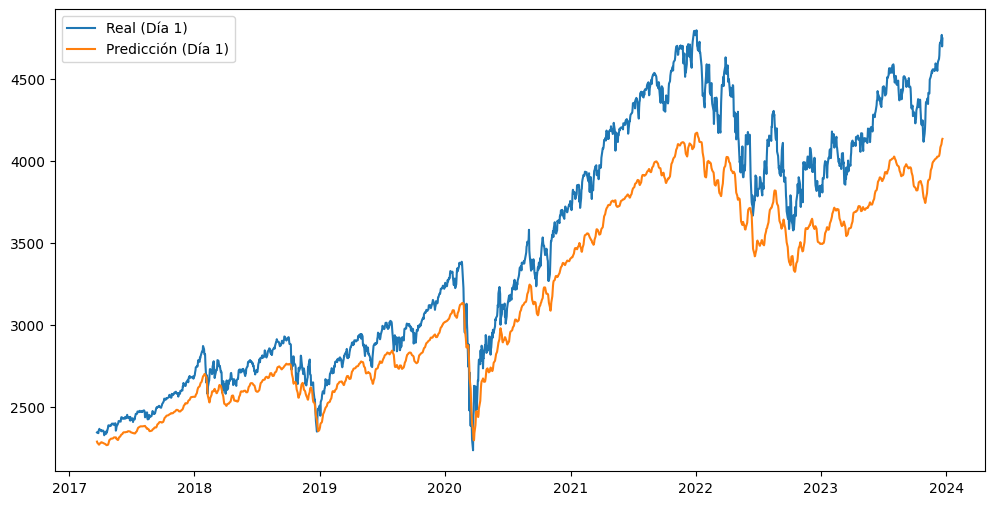

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Descargar datos del S&P 500
ticker = "^GSPC"
df = yf.download(ticker, start="1990-01-01", end="2024-01-01")
df = df[['Close']]

# Normalizar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)

# Definir la cantidad de días a predecir
seq_length = 60  # Usamos 60 días de historial
forecast_horizon = 5  # Queremos predecir 5 días en el futuro

# Crear secuencias de datos
def create_sequences(data, seq_length, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - seq_length - forecast_horizon):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length:i+seq_length+forecast_horizon].flatten())
    return np.array(X), np.array(y)

X, y = create_sequences(df_scaled, seq_length, forecast_horizon)

# Dividir en entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Definir la red neuronal para predicción multihorizonte
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(25, activation='relu'),
    Dense(forecast_horizon)  # Cambia la salida a 5 neuronas (5 días)
])

# Compilar y entrenar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

with tf.device('/GPU:0'):
    model.fit(X_train, y_train, batch_size=32, epochs=25, validation_data=(X_test, y_test))


# ... (código anterior sin cambios hasta las predicciones)

# Hacer predicciones
predictions = model.predict(X_test)

# Invertir la transformación para cada día del horizonte
predictions_unscaled = np.zeros_like(predictions)
y_test_unscaled = np.zeros_like(y_test)

for i in range(forecast_horizon):
    predictions_unscaled[:, i] = scaler.inverse_transform(predictions[:, i].reshape(-1, 1)).flatten()
    y_test_unscaled[:, i] = scaler.inverse_transform(y_test[:, i].reshape(-1, 1)).flatten()

# Calcular fechas correctas para el gráfico
test_dates = df.index[train_size + seq_length : train_size + seq_length + len(X_test)]

# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_unscaled[:, 0], label="Real (Día 1)")
plt.plot(test_dates, predictions_unscaled[:, 0], label="Predicción (Día 1)")
plt.legend()
plt.show()

## Ejemplo de predicción con relativamente pocos datos (1 de enero de 2023 - 1 de enero de 2024) usnado el mmodelo LSTMN para mostrar como pierde mucha presición, logra mostrar un poco la tendencia.


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 410ms/step - loss: 0.2511 - val_loss: 0.2537
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.0567 - val_loss: 0.0055
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0208 - val_loss: 0.0021
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0123 - val_loss: 0.0348
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0078 - val_loss: 0.0556
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0107 - val_loss: 0.0427
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0065 - val_loss: 0.0221
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0051 - val_loss: 0.0111
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0057 - val_loss: 0.0133
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0056 - val_loss: 0.0215
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0055 - val_loss: 0.0256
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0054 - val_loss: 0.022

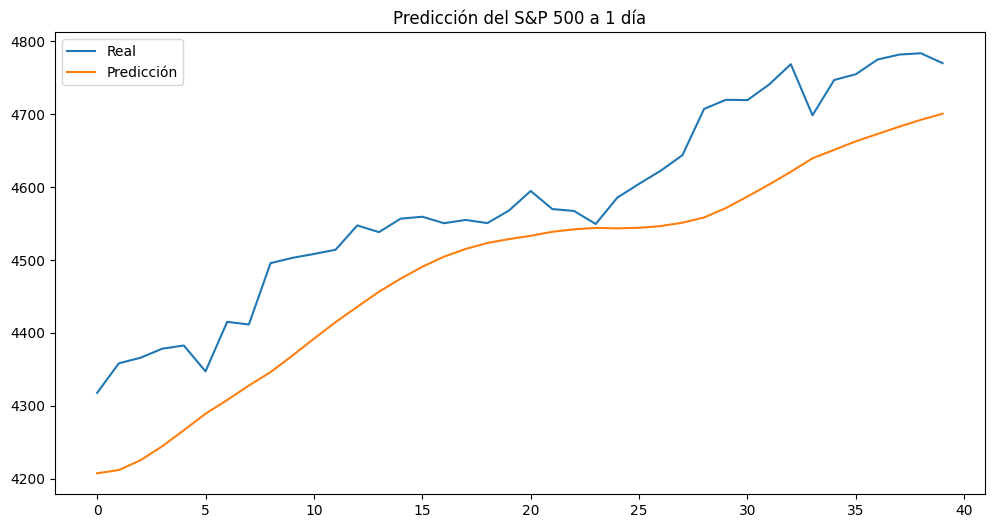

In [ ]:
# Predicción con rango corto

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import yfinance as yf

# Descargar datos del S&P 500
data = yf.download('^GSPC', start='2023-01-01', end='2024-01-01')
data = data[['Close']]

# Normalización de los datos
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Función para crear datos de entrenamiento
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 50  # Longitud de la secuencia de entrada
X, y = create_sequences(data_scaled, seq_length)

# División de datos en entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Construcción del modelo con una sola capa LSTM
model = Sequential([
    LSTM(64, input_shape=(seq_length, 1)),
    Dense(1)
])

# Compilación del modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# Entrenamiento
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Graficar resultados
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Real')
plt.plot(predictions, label='Predicción')
plt.legend()
plt.title('Predicción del S&P 500 a 1 día')
plt.show()


[*********************100%***********************]  1 of 1 completed
<ipython-input-8-3337fa3fd8f1>:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Entropy'] = entropy


Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 33s 182ms/step - loss: 0.0228 - val_loss: 0.3058
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 177ms/step - loss: 0.0018 - val_loss: 0.2109
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 41s 178ms/step - loss: 0.0041 - val_loss: 0.4202
Epoch 4/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 41s 182ms/step - loss: 0.0014 - val_loss: 0.3627
Epoch 5/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 40s 178ms/step - loss: 7.9441e-04 - val_loss: 0.3967
Epoch 6/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 40s 168ms/step - loss: 7.5650e-04 - val_loss: 0.3825
Epoch 7/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step - loss: 8.1695e-04 - val_loss: 0.4184
Epoch 8/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - loss: 7.3153e-04 - val_loss: 0.4103
Epoch 9/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 157ms/step - loss: 6.4493e-04 - val_loss: 0.4091
Epoch 10/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 42s 167ms/step - loss: 8.1339e-04 - val_loss: 0.5029
Epoch 11/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 42s 172ms/step - loss: 8.9731e-04 - val_loss

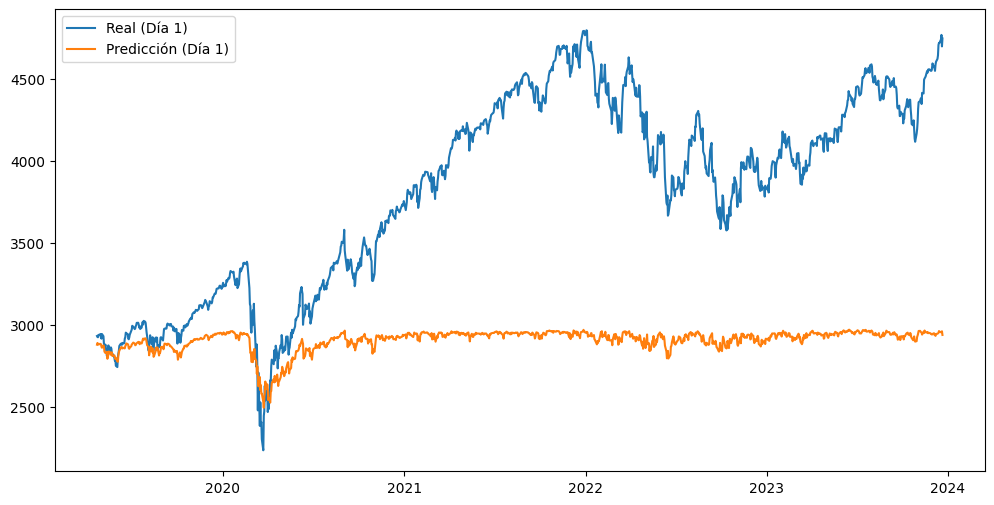

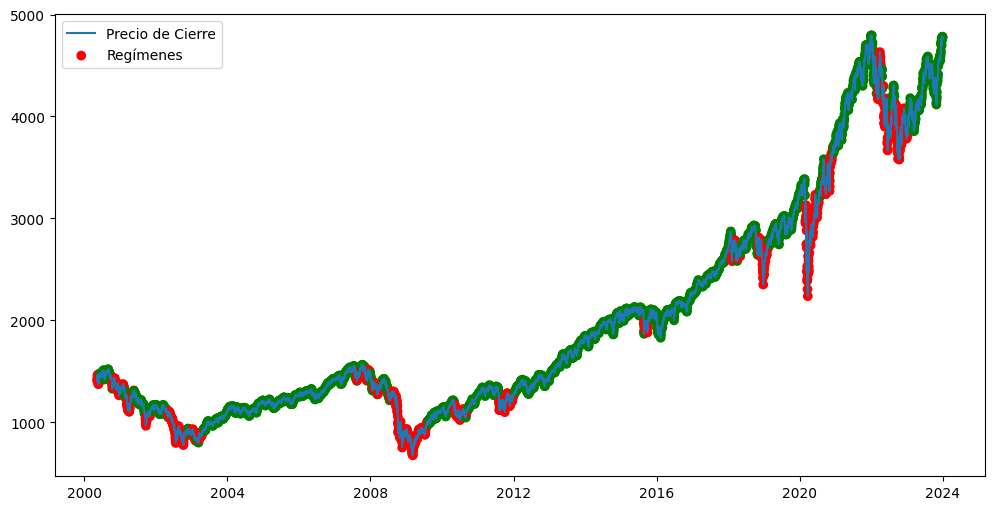

In [ ]:
# Instalar bibliotecas necesarias
!pip install yfinance tensorflow scikit-learn matplotlib

# Importar bibliotecas
import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mutual_info_score
import matplotlib.pyplot as plt

# Implementación manual del exponente de Hurst
def compute_hurst(series):
    """
    Calcula el exponente de Hurst usando el método R/S.
    :param series: Serie temporal (array de numpy o lista).
    :return: Exponente de Hurst.
    """
    n = len(series)
    max_k = int(np.floor(n / 2))
    r_s_values = []
    lags = []

    for k in range(10, max_k + 1):
        subsets = [series[i:i + k] for i in range(0, n, k)]
        if len(subsets[-1]) != k:
            subsets = subsets[:-1]  # Ignorar el último subconjunto si es incompleto
        r_s = []
        for subset in subsets:
            mean = np.mean(subset)
            deviation = subset - mean
            z = np.cumsum(deviation)
            r = np.max(z) - np.min(z)  # Rango
            s = np.std(subset)  # Desviación estándar
            r_s.append(r / s)
        r_s_values.append(np.mean(r_s))
        lags.append(k)

    # Ajuste lineal para obtener el exponente de Hurst
    hurst_exp, _ = np.polyfit(np.log(lags), np.log(r_s_values), 1)
    return hurst_exp

# 1. Descargar datos del S&P 500
ticker = "^GSPC"
df = yf.download(ticker, start="1990-01-01", end="2024-01-01")
df = df[['Close']]

# 2. Calcular retornos logarítmicos
df['Return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

# 3. Calcular métricas de econofísica
def shannon_entropy(series, window=30, bins=20):
    entropy = []
    for i in range(len(series) - window):
        sub = series[i:i+window]
        hist = np.histogram(sub, bins=bins, density=True)[0]
        entropy.append(-np.sum(hist * np.log(hist + 1e-10)))  # Evitar log(0)
    return np.array(entropy)

# Calcular entropía
entropy = shannon_entropy(df['Return'].values, window=30)

# Asegurarse de que el DataFrame tenga la misma longitud que la entropía
df = df.iloc[30:]  # Recortar el DataFrame para que coincida con la longitud de la entropía
df['Entropy'] = entropy

# Calcular Hurst y Volatilidad (ya recortado el DataFrame)
df['Hurst'] = df['Return'].rolling(60).apply(compute_hurst)
df['Volatility'] = df['Return'].rolling(30).std()
df.dropna(inplace=True)  # Eliminar filas con NaN (debido a las ventanas móviles)

# 4. Normalizar características (usando RobustScaler para outliers)
scaler = RobustScaler()
df_scaled = scaler.fit_transform(df[['Close', 'Return', 'Entropy', 'Hurst', 'Volatility']])

# 5. Crear secuencias multivariable
def create_sequences(data, seq_length, forecast_horizon, n_features=5):
    X, y = [], []
    for i in range(len(data) - seq_length - forecast_horizon):
        X.append(data[i:i+seq_length, :])  # Todas las características
        y.append(data[i+seq_length:i+seq_length+forecast_horizon, 0])  # Predecir 'Close'
    return np.array(X), np.array(y)

seq_length = 60  # Usamos 60 días de historial
forecast_horizon = 5  # Predecir 5 días en el futuro
X, y = create_sequences(df_scaled, seq_length, forecast_horizon)

# 6. Dividir en entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 7. Definir la red neuronal LSTM multivariable
input_layer = Input(shape=(seq_length, 5))
lstm_layer_1 = LSTM(100, return_sequences=True)(input_layer)
dropout_1 = Dropout(0.3)(lstm_layer_1)
lstm_layer_2 = LSTM(100, return_sequences=True)(dropout_1)
dropout_2 = Dropout(0.3)(lstm_layer_2)
lstm_layer_3 = LSTM(100)(dropout_2)
dense_layer = Dense(50, activation='relu')(lstm_layer_3)
output_layer = Dense(forecast_horizon)(dense_layer)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='mean_squared_error')

# 8. Entrenar el modelo
with tf.device('/GPU:0'):  # Asegura que la GPU se use
    history = model.fit(X_train, y_train, batch_size=32, epochs=25, validation_data=(X_test, y_test))

# 9. Hacer predicciones
predictions = model.predict(X_test)

# 10. Invertir la transformación para cada día del horizonte
predictions_unscaled = np.zeros_like(predictions)
y_test_unscaled = np.zeros_like(y_test)

for i in range(forecast_horizon):
    predictions_unscaled[:, i] = scaler.inverse_transform(
        np.concatenate([predictions[:, i].reshape(-1, 1), np.zeros((len(predictions), 4))], axis=1)
    )[:, 0]
    y_test_unscaled[:, i] = scaler.inverse_transform(
        np.concatenate([y_test[:, i].reshape(-1, 1), np.zeros((len(y_test), 4))], axis=1)
    )[:, 0]

# 11. Graficar los resultados
test_dates = df.index[train_size + seq_length : train_size + seq_length + len(X_test)]

plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_unscaled[:, 0], label="Real (Día 1)")
plt.plot(test_dates, predictions_unscaled[:, 0], label="Predicción (Día 1)")
plt.legend()
plt.show()

# 12. Análisis de regímenes de mercado
threshold_entropy = np.percentile(df['Entropy'], 75)
df['Regime'] = np.where(df['Entropy'] > threshold_entropy, 'Caos', 'Calma')

# 13. Visualización de regímenes
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label="Precio de Cierre")
plt.scatter(df.index, df['Close'], c=df['Regime'].map({'Caos': 'red', 'Calma': 'green'}), label="Regímenes")
plt.legend()
plt.show()

In [ ]:
# Herst

import yfinance as yf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import linregress

# Descargar datos del S&P 500
ticker = "^GSPC"
data = yf.download(ticker, period="5y", interval="1d")
prices = data['Close'].values

# Normalizar los datos
scaler = MinMaxScaler()
prices_norm = scaler.fit_transform(prices.reshape(-1, 1)).flatten()

# Calcular log-retornos
returns = np.diff(np.log(prices_norm))

# Función para calcular el índice de multifractalidad
def multifractal_index(ts, q_range=range(-5, 6)):
    fluctuations = []
    for q in q_range:
        if q == 0:
            continue
        moments = np.mean(np.abs(ts) ** q) ** (1 / q)
        fluctuations.append(moments)
    slope, _, _, _, _ = linregress(q_range[1:], np.log(fluctuations))
    return slope

# Crear datos para la red neuronal
window_size = 30
X, y = [], []
for i in range(len(returns) - window_size):
    X.append(returns[i:i + window_size])
    y.append(multifractal_index(returns[i:i + window_size]))
X, y = np.array(X), np.array(y)

# Construir la red neuronal con más capas y regularización para mejorar la precisión
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(window_size,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse')

# Entrenar la red neuronal con early stopping para evitar sobreajuste
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model.fit(X, y, epochs=200, batch_size=8, verbose=1, validation_split=0.1, callbacks=[early_stopping])

# Predecir el índice de multifractalidad
multi_index_pred = model.predict(X)

# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(y, label='Índice de multifractalidad real', linestyle='dashed')
plt.plot(multi_index_pred, label='Índice de multifractalidad predicho', alpha=0.7)
plt.xlabel('Días')
plt.ylabel('Índice de Multifractalidad')
plt.title('Predicción del Índice de Multifractalidad del S&P 500')
plt.legend()
plt.show()


## Aplicación del modelo LSTM en una red neuronal para la predicción del indice de Hurst a partir del historico de precios del S&P500 del 1 de enero de 1990 hasta el 1 de enero de 2024.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import linregress
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# =============================================================================
# Función para calcular el exponente de Hurst usando el método R/S
# =============================================================================
def hurst_rs(ts, window_min, window_max, num_windows=50):
    """
    Calcula el exponente de Hurst de la serie 'ts' usando el método R/S.

    Para cada tamaño de ventana m (elegido en escala logarítmica entre window_min y window_max),
    se divide la serie en segmentos completos, se calcula el perfil (cumsum de las desviaciones
    respecto a la media) y se obtiene el rango R y la desviación estándar S para cada segmento.
    Luego se realiza una regresión lineal en el espacio log-log: log(R/S) = H·log(m) + c.

    Parámetros:
      ts         : array unidimensional con la serie temporal.
      window_min : tamaño mínimo de ventana.
      window_max : tamaño máximo de ventana.
      num_windows: cantidad de tamaños de ventana a evaluar.

    Retorna:
      slope      : exponente de Hurst estimado.
    """
    N = len(ts)
    # Genera tamaños de ventana únicos en escala logarítmica
    window_sizes = np.unique(np.floor(np.logspace(np.log10(window_min), np.log10(window_max), num_windows)).astype(int))
    m_values = []
    rs_values = []

    for m in window_sizes:
        if m < window_min:
            continue
        n_segments = N // m  # número de segmentos completos en la serie
        rs_seg = []
        for i in range(n_segments):
            segment = ts[i*m:(i+1)*m]
            seg_mean = np.mean(segment)
            # Cálculo del perfil (desviaciones acumuladas)
            Y = np.cumsum(segment - seg_mean)
            R = np.max(Y) - np.min(Y)
            S = np.std(segment)
            if S > 0:
                rs_seg.append(R / S)
        if len(rs_seg) > 0:
            m_values.append(m)
            rs_values.append(np.mean(rs_seg))

    log_m = np.log(m_values)
    log_rs = np.log(rs_values)
    slope, intercept, r_value, p_value, std_err = linregress(log_m, log_rs)
    return slope

# =============================================================================
# 1. Descarga de datos del SP500 (1/1/1990 - 1/1/2024)
# =============================================================================
ticker = '^GSPC'
start_date = '1990-01-01'
end_date   = '2024-01-01'
data = yf.download(ticker, start=start_date, end=end_date)
if data.empty:
    raise ValueError("No se pudieron descargar los datos. Revisa tu conexión o el ticker.")

# Usamos el precio ajustado
prices = data['Close']

# =============================================================================
# 2. Calcular retornos logarítmicos diarios
# =============================================================================
log_prices = np.log(prices)
returns = log_prices.diff().dropna()  # Retornos diarios (serie estacionaria)

# =============================================================================
# 3. Cálculo del exponente de Hurst en ventana móvil (para alimentar la red)
# =============================================================================
window_size = 500   # Número de días por ventana (puedes ajustar)
step = 10           # Paso entre ventanas

hurst_values = []   # Para almacenar el Hurst de cada ventana
hurst_dates = []    # Fecha (central) de cada ventana

for i in range(0, len(returns) - window_size, step):
    window_data = returns.iloc[i:i+window_size].values
    # Calculamos Hurst usando tamaños entre 10 y window_size//2
    H = hurst_rs(window_data, window_min=10, window_max=window_size//2, num_windows=30)
    hurst_values.append(H)
    hurst_dates.append(returns.index[i + window_size//2])

hurst_series = pd.Series(hurst_values, index=hurst_dates)

# Graficar la evolución del exponente de Hurst (teórico)
plt.figure(figsize=(12,6))
plt.plot(hurst_series.index, hurst_series.values, marker='o', linestyle='-', label="Hurst Teórico")
plt.xlabel("Fecha")
plt.ylabel("Exponente de Hurst")
plt.title("Evolución del Exponente de Hurst (retornos diarios del SP500)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# 4. Preparar datos para la red LSTM
# =============================================================================
# Convertir la serie de Hurst a un arreglo numpy y escalar los datos
hurst_arr = hurst_series.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
hurst_scaled = scaler.fit_transform(hurst_arr)

# Función para crear secuencias de datos (ventana deslizante)
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 5  # Número de valores pasados usados para predecir el siguiente
X, y = create_sequences(hurst_scaled, seq_length=seq_length)
print("X shape:", X.shape, "y shape:", y.shape)

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# =============================================================================
# 5. Construir y entrenar la red LSTM
# =============================================================================
model = Sequential()
model.add(LSTM(50, activation='tanh', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

print(model.summary())

# Entrenar la red
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# =============================================================================
# 6. Evaluar y graficar la predicción
# =============================================================================
y_pred = model.predict(X_test)

# Invertir la escala para obtener los valores originales
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# Crear un índice temporal para los datos de prueba
test_dates = hurst_series.index[seq_length + train_size: seq_length + train_size + len(y_test_inv)]

plt.figure(figsize=(12,6))
plt.plot(test_dates, y_test_inv, label="Valor Real Hurst")
plt.plot(test_dates, y_pred_inv, label="Predicción LSTM", linestyle='--')
plt.xlabel("Fecha")
plt.ylabel("Exponente de Hurst")
# plt.title("Predicción del Exponente de Hurst del SP500 con LSTM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =============================================================================
# 7. Imprimir los valores globales: Teórico y Predicho
# =============================================================================
# Valor teórico: promedio de los valores de Hurst obtenidos en ventanas móviles
theoretical_hurst = np.mean(hurst_series.values)
# Valor predicho: promedio de las predicciones en el conjunto de prueba
predicted_hurst = np.mean(y_pred_inv)

print("Valor teórico promedio del índice de Hurst del SP500:", theoretical_hurst)
print("Valor predicho promedio por la red neuronal:", predicted_hurst)



[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


ValueError: No se pudieron descargar los datos. Revisa tu conexión o el ticker.

## Aplicación del modelo LSTM en una red neuronal para la predicción de la entropía de Shannon, a partir del historico de precios del S&P500 del 1 de enero de 1990 hasta el 1 de enero de 2024


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Función para calcular la entropía de Shannon a partir de una muestra de datos
def shannon_entropy(data, bins=30):
    counts, _ = np.histogram(data, bins=bins)
    probabilities = counts / counts.sum()
    # Evitar logaritmo de cero
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

# 2. Descarga de datos históricos del S&P500
ticker = "^GSPC"
start_date = "1990-01-01"
end_date = "2024-01-01"
data = yf.download(ticker, start=start_date, end=end_date)
prices = data['Close']

# 3. Cálculo de los retornos logarítmicos diarios
returns = np.log(prices / prices.shift(1)).dropna()

# 4. Cálculo de la entropía de Shannon con una ventana móvil (252 días ≈ 1 año)
window = 252
rolling_entropy = returns.rolling(window=window).apply(lambda x: shannon_entropy(x, bins=30), raw=True)
entropy_series = rolling_entropy.dropna()  # Eliminar los NaN iniciales

# 5. Preparación del dataset para la red LSTM
# Convertimos la serie en array y escalamos los valores para facilitar el entrenamiento
entropy_values = entropy_series.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_entropy = scaler.fit_transform(entropy_values)

# Se crea un dataset de secuencias: cada muestra son 30 días y la etiqueta es el valor en el día siguiente
sequence_length = 30
X, y_seq = [], []
for i in range(len(scaled_entropy) - sequence_length):
    X.append(scaled_entropy[i:i+sequence_length])
    y_seq.append(scaled_entropy[i+sequence_length])
X = np.array(X)
y_seq = np.array(y_seq)

# División en conjunto de entrenamiento y prueba (80% - 20%)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

# 6. Construcción y entrenamiento del modelo LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

print("Entrenando la red LSTM...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# 7. Predicción sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Inversa de la escala para comparar en las unidades originales (bits)
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# 8. Obtener las fechas correspondientes a los datos de prueba.
# Debido a la ventana y la división, los índices se deben ajustar:
test_dates = entropy_series.index[sequence_length + train_size:]

# 9. Gráfica de comparación entre la entropía teórica y la predicción de la LSTM
plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_inv, label='Entropía teórica')
plt.plot(test_dates, y_pred_inv, label='Predicción LSTM', linestyle='--')
# plt.title("Comparación entre Entropía Teórica y Predicción LSTM")
plt.xlabel("Fecha")
plt.ylabel("Entropía de Shannon (bits)")
plt.legend()
plt.grid(True)
plt.show()


[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by MinMaxScaler.

## Aplicación del modelo LSTM en una red neuronal para la predicción de la fractalidad a partir del historico de precios del S&P500 del 1 de enero de 1990 hasta el 1 de enero de 2024



In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ---------------------------
# Función para calcular la fractalidad mediante el método de Higuchi
# ---------------------------
def higuchi_fd(x, kmax=10):
    """
    Calcula el fractal dimension (FD) de una serie temporal x utilizando el método de Higuchi.

    Parámetros:
        x: array-like, la serie temporal (1D)
        kmax: entero, número máximo de sub-series (típicamente 10)

    Retorna:
        fd: fractal dimension estimado
    """
    N = len(x)
    L = []  # Lista para almacenar la longitud promedio para cada k
    for k in range(1, kmax+1):
        Lk = []
        for m in range(k):
            # Número de segmentos para este m y k
            n_max = int(np.floor((N - m) / k))
            if n_max > 1:
                # Calcular la longitud de la curva para la subserie
                Lmk = np.sum(np.abs(np.diff(x[m: m + n_max*k: k])))
                # Normalización según el método de Higuchi
                norm_factor = (N - 1) / (n_max * k)
                Lmk = Lmk * norm_factor
                Lk.append(Lmk)
        if len(Lk) > 0:
            L.append(np.mean(Lk))
    L = np.array(L)

    # Realizar la regresión lineal en el espacio log-log
    # Se usa log(1/k) en lugar de log(k) para obtener directamente la FD
    ln_k = np.log(1.0 / np.arange(1, kmax+1))
    ln_L = np.log(L)
    slope, intercept = np.polyfit(ln_k, ln_L, 1)
    # El slope obtenido es el fractal dimension
    return slope

# ---------------------------
# 1. Descarga de datos históricos del S&P500
# ---------------------------
ticker = "^GSPC"
start_date = "1990-01-01"
end_date = "2024-01-01"
data = yf.download(ticker, start=start_date, end=end_date)
prices = data['Close']

# ---------------------------
# 2. Cálculo de los retornos logarítmicos diarios
# ---------------------------
returns = np.log(prices / prices.shift(1)).dropna()

# ---------------------------
# 3. Estimación de la fractalidad (fractal dimension) con ventana móvil
# ---------------------------
window = 252  # Aproximadamente un año de negociación
# Usamos una función lambda que aplica el método de Higuchi a cada ventana
rolling_fd = returns.rolling(window=window).apply(lambda x: higuchi_fd(x, kmax=10), raw=True)
fd_series = rolling_fd.dropna()  # Eliminar los NaN iniciales

# ---------------------------
# 4. Preparación del dataset para entrenar la red LSTM
# ---------------------------
# Convertimos la serie en array y escalamos los valores (entre 0 y 1)
fd_values = fd_series.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_fd = scaler.fit_transform(fd_values)

# Creamos un dataset de secuencias: cada muestra tendrá 30 días y la etiqueta es el valor al día siguiente
sequence_length = 30
X, y_seq = [], []
for i in range(len(scaled_fd) - sequence_length):
    X.append(scaled_fd[i:i+sequence_length])
    y_seq.append(scaled_fd[i+sequence_length])
X = np.array(X)
y_seq = np.array(y_seq)

# División en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

# ---------------------------
# 5. Construcción y entrenamiento del modelo LSTM
# ---------------------------
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

print("Entrenando la red LSTM...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# ---------------------------
# 6. Predicción sobre el conjunto de prueba
# ---------------------------
y_pred = model.predict(X_test)

# Inversa de la escala para comparar en las unidades originales
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# ---------------------------
# 7. Graficar la comparación entre la fractalidad teórica y la predicción de la LSTM
# ---------------------------
# Debido a la ventana y la división, ajustamos las fechas:
test_dates = fd_series.index[sequence_length + train_size:]

plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_inv, label='Fractalidad Teórica')
plt.plot(test_dates, y_pred_inv, label='Predicción LSTM', linestyle='--')
# plt.title("Comparación entre Fractalidad Teórica y Predicción LSTM del S&P500")
plt.xlabel("Fecha")
plt.ylabel("Fractal Dimension (FD)")
plt.legend()
plt.grid(True)
plt.show()


## Aplicación del modelo LSTM en una red neuronal para la predicción de la volatilidad a partir del historico de precios del S&P500 del 1 de enero de 1990 hasta el 1 de enero de 2024

In [ ]:
# volatilidad pro


import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler

# Descargar datos históricos del S&P 500 con manejo de errores
try:
    sp500 = yf.download('^GSPC', start="1994-02-01", end="2024-02-01")

    if sp500.empty:
        raise ValueError("No se pudieron descargar los datos del S&P 500.")

    if 'Adj Close' in sp500.columns:
        sp500 = sp500['Adj Close']
    else:
        sp500 = sp500['Close']

    print("Datos descargados correctamente.")
except Exception as e:
    print(f"Error al descargar datos: {e}")
    exit()

# Calcular los rendimientos logarítmicos
returns = np.log(sp500 / sp500.shift(1)).dropna()

# Función para calcular la volatilidad histórica
def compute_volatility(series):
    return np.std(series) * np.sqrt(252)  # Anualizada

# Crear ventanas de datos para la red neuronal
window_size = 60  # 60 días de datos para predecir la volatilidad
X, y = [], []

for i in range(len(returns) - window_size):
    window = returns[i:i + window_size].values
    X.append(window)
    y.append(compute_volatility(window))

X, y = np.array(X), np.array(y)

# Normalización mejorada
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))  # La volatilidad no debe ser negativa
X = scaler_X.fit_transform(X.reshape(X.shape[0], -1)).reshape(X.shape[0], window_size, 1)
y = scaler_y.fit_transform(y.reshape(-1, 1))

# Definir la red neuronal mejorada
model = Sequential([
    LSTM(128, activation='relu', return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),  # Evita sobreajuste
    LSTM(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Salida única: volatilidad
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Entrenar la red neuronal
model.fit(X, y, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Hacer predicciones
y_pred = scaler_y.inverse_transform(model.predict(X))

# Graficar la volatilidad real vs predicha
plt.figure(figsize=(10, 5))
plt.plot(y, label="Volatilidad Real", alpha=0.6)
plt.plot(y_pred, label="Volatilidad Predicha", linestyle='dashed', color='red')
plt.title("Predicción de Volatilidad con LSTM")
plt.legend()
plt.show()


## Corroboración teorica del calculo de la serie en el tiempo del indice de Hurst del SP500

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import yfinance as yf

# =============================================================================
# Función para calcular el exponente de Hurst usando el método R/S
# =============================================================================
def hurst_rs(ts, window_min, window_max, num_windows=50):
    """
    Calcula el exponente de Hurst de la serie 'ts' usando el método R/S.

    Para cada tamaño de ventana m (elegido en escala logarítmica entre window_min y window_max),
    se divide la serie en segmentos completos, se calcula el perfil (cumsum de las desviaciones
    respecto a la media) y se obtiene el rango R y la desviación estándar S para cada segmento.
    Se calcula R/S para cada segmento y se promedia para ese tamaño de ventana.
    Finalmente se realiza una regresión lineal en el espacio log-log: log(R/S) = H·log(m) + c.

    Parámetros:
      ts         : array unidimensional con la serie temporal.
      window_min : tamaño mínimo de ventana.
      window_max : tamaño máximo de ventana.
      num_windows: cantidad de tamaños de ventana a evaluar.

    Retorna:
      slope      : exponente de Hurst estimado.
    """
    N = len(ts)
    # Genera tamaños de ventana únicos (enteros) en escala logarítmica
    window_sizes = np.unique(np.floor(np.logspace(np.log10(window_min), np.log10(window_max), num_windows)).astype(int))
    m_values = []
    rs_values = []

    for m in window_sizes:
        if m < window_min:
            continue
        n_segments = N // m  # número de segmentos completos en la serie
        rs_seg = []
        for i in range(n_segments):
            segment = ts[i*m:(i+1)*m]
            seg_mean = np.mean(segment)
            # Cálculo del perfil (desviaciones acumuladas)
            Y = np.cumsum(segment - seg_mean)
            R = np.max(Y) - np.min(Y)
            S = np.std(segment)
            if S > 0:
                rs_seg.append(R / S)
        if len(rs_seg) > 0:
            m_values.append(m)
            rs_values.append(np.mean(rs_seg))

    log_m = np.log(m_values)
    log_rs = np.log(rs_values)
    slope, intercept, r_value, p_value, std_err = linregress(log_m, log_rs)
    return slope

# =============================================================================
# 1. Descarga del histórico del SP500 (del 1/1/1990 al 1/1/2024)
# =============================================================================
ticker = '^GSPC'
start_date = '1990-01-01'
end_date   = '2024-01-01'
data = yf.download(ticker, start=start_date, end=end_date)
if data.empty:
    raise ValueError("No se pudieron descargar los datos. Revisa tu conexión a Internet o el ticker.")

# Usamos el precio ajustado
prices = data['Adj Close']

# =============================================================================
# 2. Cálculo de los retornos logarítmicos diarios
# =============================================================================
log_prices = np.log(prices)
returns = log_prices.diff().dropna()  # Retornos diarios; serie estacionaria

# =============================================================================
# 3. Cálculo del exponente de Hurst en ventana móvil (rolling window)
# =============================================================================
# Parámetros de la ventana móvil
window_size = 500  # Número de días (puedes ajustar; por ejemplo, 500 días)
step = 10          # Paso entre ventanas

hurst_values = []  # Lista para almacenar el Hurst de cada ventana
dates = []         # Lista para almacenar la fecha (por ejemplo, la fecha central de la ventana)

for i in range(0, len(returns) - window_size, step):
    window_data = returns.iloc[i:i+window_size].values  # Datos de la ventana
    # Usamos la función hurst_rs para la ventana; evaluamos tamaños de ventana entre 10 y window_size//2
    H = hurst_rs(window_data, window_min=10, window_max=window_size//2, num_windows=30)
    hurst_values.append(H)
    # Asignamos la fecha central de la ventana
    dates.append(returns.index[i + window_size//2])

# Convertir a Series de pandas para graficar
hurst_series = pd.Series(hurst_values, index=dates)

# =============================================================================
# 4. Graficar la evolución del exponente de Hurst en el tiempo
# =============================================================================
plt.figure(figsize=(12,6))
plt.plot(hurst_series.index, hurst_series.values, marker='o', linestyle='-')
plt.xlabel('Fecha')
plt.ylabel('Exponente de Hurst')
# plt.title('Evolución del Exponente de Hurst (retornos diarios del SP500)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Corroboración teorica del calculo de la serie en el tiempo de la entropía de Shannon del SP500

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Función para calcular la entropía de Shannon a partir de una muestra de datos
def shannon_entropy(data, bins=30):
    counts, _ = np.histogram(data, bins=bins)
    probabilities = counts / counts.sum()
    # Evitar logaritmos de ceros
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

# Parámetros de descarga
ticker = "^GSPC"
start_date = "1990-01-01"
end_date = "2024-01-01"

# Descarga de datos históricos
data = yf.download(ticker, start=start_date, end=end_date)
prices = data['Close']

# Calcular los retornos logarítmicos diarios y eliminar NaN
returns = np.log(prices / prices.shift(1)).dropna()

# Tamaño de la ventana móvil (por ejemplo, 252 días ≈ 1 año)
window = 252

# Calcular la entropía de Shannon en una ventana móvil
rolling_entropy = returns.rolling(window=window).apply(lambda x: shannon_entropy(x, bins=30), raw=True)

# Graficar la entropía móvil
plt.figure(figsize=(10, 6))
plt.plot(rolling_entropy.index, rolling_entropy, label='Entropía de Shannon')
# plt.title('Entropía de Shannon móvil de los retornos logarítmicos diarios del S&P500')
plt.xlabel('Fecha')
plt.ylabel('Entropía (bits)')
plt.legend()
plt.grid(True)
plt.show()